# UCI HAR Classification - ResNet + CBAM

ResNet만 썼을 때는 residual connection을 통해 깊은 네크워크 안에서도 좋은 feature를 안정적으로 특징 추출이 가능해진다.

CBAM은 channel attention과 spatial attention으로 활동 구분에 중요한 센서 특징과 시간 구간에 더 집중하여 활동 분류 성능을 높일 수 있다.

**따라서 이 두 모델을 합치면 어떤 점이 좋아질까?**

ResNet만으로 깊은 네트워크에서 좋은 feature를 추출하더라도 모든 feature와 모든 시간 구이 동일한 중요도를 가지게 되기 때문에 CBAM으로 그 feature 중 분류에 더 중요한 특징과 시간 구간에 집중하도록 하여 활동 분류 성능을 한층 더 높일 수 있게 된다.



In [1]:
# 라이브러리 import
import os
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix

# 재현성을 위한 seed 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

#GPU가 켜져 있으면 cuda를 사용하고 GPU가 없으면 자동으로 cpu를 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


In [2]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/UCI HAR Dataset/"

TRAIN = "train/"
TEST = "test/"

# 입력으로 사용할 9개의 센서 채널
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

# 혼동 행렬이나 결과 해석 시 읽기 쉬운 동작 이름 정의
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]


In [4]:
# X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = [] # 전체 센서 채널(9개)을 담을 리스트

    # 센서 파일(9개)을 하나씩 순회
    for signal_type_path in X_signals_paths:
        signal_data = [] # 현재 센서 채널의 모든 샘플 데이터를 담을 리스트

        with open(signal_type_path, 'r') as file:
            for row in file:

                # 문자열 전처리
                row = row.replace('  ', ' ').strip().split(' ')

                # 문자열 → float32 숫자로 변환
                row = [np.float32(x) for x in row]

                # 하나의 sample을 리스트에 추가
                signal_data.append(row)

        # 현재 센서 채널 전체 데이터를 추가
        X_signals.append(signal_data)

    # 리스트 -> numpy 배열로 변환
    X_signals = np.array(X_signals)

    # 원래 shape: (9, samples, 128)
    # 변환 후 shape: (samples, 128, 9)
    return np.transpose(X_signals, (1, 2, 0))


In [5]:
# y 데이터 로드 함수
def load_y(y_path):
    y = [] # 전체 샘플의 정답 라벨을 담을 리스트
    with open(y_path, 'r') as file:
        for row in file:
            y.append(int(row.strip()))

    # 원래 라벨이 1~6이라서 PyTorch CrossEntropyLoss에서 사용하도록 0~5로 변경
    y = np.array(y, dtype=np.int64)
    return y - 1


In [6]:
# 데이터 로드

# train용 9개 센서 파일 경로를 리스트로 생성
X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# test용 9개 센서 파일 경로를 리스트로 생성
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

# train 입력 데이터 로드
X_train = load_X(X_train_signals_paths)
# test 입력 데이터 로드
X_test = load_X(X_test_signals_paths)

# train 정답 라벨 로드
y_train = load_y(DATASET_PATH + TRAIN + "y_train.txt")
# test 정답 라벨 로드
y_test = load_y(DATASET_PATH + TEST + "y_test.txt")

print("X_train shape:", X_train.shape) # (samples, time, channels)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (7352,)
y_test shape: (2947,)


In [7]:
# 데이터 표준화
# train 데이터 기준으로 평균과 표준편차를 계산하고, train/test에 동일하게 적용

mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std


In [8]:
# PyTorch Tensor 변환
# Keras Conv1D 입력: (batch, time, channel)
# PyTorch Conv1d 입력: (batch, channel, time)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train_tensor shape:", X_train_tensor.shape) # (samples, channels, time)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)


X_train_tensor shape: torch.Size([7352, 9, 128])
X_test_tensor shape: torch.Size([2947, 9, 128])
y_train_tensor shape: torch.Size([7352])
y_test_tensor shape: torch.Size([2947])


In [9]:
# Dataset / DataLoader 생성
batch_size = 64
val_ratio = 0.2

full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_size = int(len(full_train_dataset) * val_ratio)
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Train samples: 5882
Validation samples: 1470
Test samples: 2947


In [10]:
# Gaussian Noise Layer
class GaussianNoise(nn.Module):
    def __init__(self, std=0.01):
        super().__init__()
        self.std = std

    def forward(self, x):
        # Keras GaussianNoise처럼 train 모드에서만 noise 추가
        if self.training and self.std > 0:
            noise = torch.randn_like(x) * self.std
            return x + noise
        return x


# Channel Attention 정의
class ChannelAttention(nn.Module):
    def __init__(self, channels, ratio=16):
        super().__init__()
        reduction = max(channels // ratio, 1)

        # 시간축 전체를 평균/최대로 압축한 뒤 같은 MLP를 공유
        self.shared_mlp = nn.Sequential(
            nn.Linear(channels, reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduction, channels, bias=False)
        )

    def forward(self, x):
        # x: (batch, channels, time)
        avg_pool = torch.mean(x, dim=2)       # (batch, channels)
        max_pool = torch.max(x, dim=2).values # (batch, channels)

        avg_out = self.shared_mlp(avg_pool)
        max_out = self.shared_mlp(max_pool)

        scale = torch.sigmoid(avg_out + max_out).unsqueeze(2) # (batch, channels, 1)
        return x * scale


# Temporal Attention 정의
class TemporalAttention(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()

        self.avg_conv = nn.Conv1d(channels, 1, kernel_size=1, padding=0, bias=False)
        self.max_conv = nn.Conv1d(channels, 1, kernel_size=1, padding=0, bias=False)

        padding = kernel_size // 2
        self.attn_conv = nn.Conv1d(
            2, 1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )

    def forward(self, x):
        # x: (batch, channels, time)
        avg_pool = self.avg_conv(x) # (batch, 1, time)
        max_pool = self.max_conv(x) # (batch, 1, time)

        concat = torch.cat([avg_pool, max_pool], dim=1) # (batch, 2, time)
        scale = torch.sigmoid(self.attn_conv(concat))   # (batch, 1, time)
        return x * scale


# CBAM Block 정의: Channel Attention -> Temporal Attention 순서로 적용
class CBAMBlock(nn.Module):
    def __init__(self, channels, ratio=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, ratio=ratio)
        self.temporal_attention = TemporalAttention(channels, kernel_size=kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.temporal_attention(x)
        return x


In [11]:
# Residual + CBAM Block 정의
class ResidualCBAMBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, pool=True, ratio=16, attn_kernel=7):
        super().__init__()
        padding = kernel_size // 2
        self.pool = pool

        # 입력 채널 수와 출력 채널 수가 다르면 1x1 Conv로 shortcut 차원을 맞춤
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, padding=0, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.cbam = CBAMBlock(out_channels, ratio=ratio, kernel_size=attn_kernel)
        self.max_pool = nn.MaxPool1d(kernel_size=2) if pool else nn.Identity()

    def forward(self, x):
        shortcut = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 중요한 채널과 중요한 시간 구간을 강조
        out = self.cbam(out)

        # Residual 연결
        out = out + shortcut
        out = self.relu(out)

        # 필요 시 시간 길이를 절반으로 줄임
        out = self.max_pool(out)
        return out


In [12]:
# ResNet + CBAM 모델 정의
class ResNetCBAM1D(nn.Module):
    def __init__(self, input_channels=9, num_classes=6):
        super().__init__()

        # 약한 노이즈 추가: 특정 데이터에 대한 과적합 방지
        self.noise = GaussianNoise(std=0.01)

        # 초기 Conv: 센서 시계열의 기본 local temporal pattern 추출
        self.stem = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2)
        )

        # Residual + CBAM blocks
        self.block1 = ResidualCBAMBlock(64, 64, kernel_size=3, pool=False, ratio=16, attn_kernel=7)
        self.block2 = ResidualCBAMBlock(64, 128, kernel_size=3, pool=True, ratio=16, attn_kernel=7)
        self.block3 = ResidualCBAMBlock(128, 256, kernel_size=3, pool=True, ratio=16, attn_kernel=7)

        # Global Average Pooling + Classifier
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (batch, channels, time)
        x = self.noise(x)
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x).squeeze(-1) # (batch, 256)
        logits = self.classifier(x)
        return logits


In [13]:
# 모델 생성
input_channels = X_train_tensor.shape[1] # 9
num_classes = 6

model = ResNetCBAM1D(input_channels=input_channels, num_classes=num_classes).to(device)

# 파라미터 수 확인
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Trainable parameters: {count_parameters(model):,}")


ResNetCBAM1D(
  (noise): GaussianNoise()
  (stem): Sequential(
    (0): Conv1d(9, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block1): ResidualCBAMBlock(
    (shortcut): Identity()
    (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (cbam): CBAMBlock(
      (channel_attention): ChannelAttention(
        (shared_mlp): Sequential(
          (0): Linear(in_features=64, out_features=4, bias=False)
          (1): ReLU(inplace=True)
         

In [14]:
# 학습 설정
learning_rate = 3e-4
epochs = 100

criterion = nn.CrossEntropyLoss(label_smoothing=0.02)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Keras ReduceLROnPlateau와 유사하게 val_loss가 정체되면 learning rate 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=10,
    min_lr=1e-6
)

checkpoint_path = "UCI_HAR_ResNet_CBAM_best_pytorch.pt"
early_stopping_patience = 15


In [15]:
# 학습/평가 함수 정의
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        running_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [16]:
# 모델 학습
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

best_val_acc = 0.0
best_model_state = copy.deepcopy(model.state_dict())
early_stopping_counter = 0

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch [{epoch:03d}/{epochs}] "
        f"loss: {train_loss:.4f} acc: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f} | "
        f"lr: {current_lr:.6f}"
    )

    # ModelCheckpoint: validation accuracy가 가장 높을 때 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, checkpoint_path)
        early_stopping_counter = 0
        print(f"  -> Best model saved. val_acc: {best_val_acc:.4f}")
    else:
        early_stopping_counter += 1

    # EarlyStopping
    if early_stopping_counter >= early_stopping_patience:
        print(f"Early stopping at epoch {epoch}")
        break

# 가장 좋은 모델 weight 복원
model.load_state_dict(best_model_state)


Epoch [001/100] loss: 0.6011 acc: 0.8604 | val_loss: 0.2313 val_acc: 0.9524 | lr: 0.000300
  -> Best model saved. val_acc: 0.9524
Epoch [002/100] loss: 0.2496 acc: 0.9466 | val_loss: 0.2101 val_acc: 0.9585 | lr: 0.000300
  -> Best model saved. val_acc: 0.9585
Epoch [003/100] loss: 0.2363 acc: 0.9498 | val_loss: 0.1970 val_acc: 0.9592 | lr: 0.000300
  -> Best model saved. val_acc: 0.9592
Epoch [004/100] loss: 0.2324 acc: 0.9487 | val_loss: 0.1981 val_acc: 0.9626 | lr: 0.000300
  -> Best model saved. val_acc: 0.9626
Epoch [005/100] loss: 0.2238 acc: 0.9510 | val_loss: 0.1983 val_acc: 0.9612 | lr: 0.000300
Epoch [006/100] loss: 0.2171 acc: 0.9565 | val_loss: 0.1937 val_acc: 0.9626 | lr: 0.000300
Epoch [007/100] loss: 0.2161 acc: 0.9560 | val_loss: 0.1821 val_acc: 0.9673 | lr: 0.000300
  -> Best model saved. val_acc: 0.9673
Epoch [008/100] loss: 0.2094 acc: 0.9563 | val_loss: 0.1811 val_acc: 0.9639 | lr: 0.000300
Epoch [009/100] loss: 0.2115 acc: 0.9595 | val_loss: 0.1937 val_acc: 0.9633 |

<All keys matched successfully>

In [17]:
# 저장된 best model 불러오기
model = ResNetCBAM1D(input_channels=input_channels, num_classes=num_classes).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()


ResNetCBAM1D(
  (noise): GaussianNoise()
  (stem): Sequential(
    (0): Conv1d(9, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block1): ResidualCBAMBlock(
    (shortcut): Identity()
    (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (cbam): CBAMBlock(
      (channel_attention): ChannelAttention(
        (shared_mlp): Sequential(
          (0): Linear(in_features=64, out_features=4, bias=False)
          (1): ReLU(inplace=True)
         

In [18]:
# 학습 및 테스트 성능 평가
train_eval_loader = DataLoader(full_train_dataset, batch_size=batch_size, shuffle=False)

train_loss, train_acc = evaluate(model, train_eval_loader, criterion, device)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")


Training accuracy: 99.69%
Training loss: 0.1234
Test accuracy: 96.06%
Test loss: 0.2400


In [19]:
# 예측 및 분류 리포트
@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    all_preds = []
    all_probs = []

    for X_batch, _ in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_pred_proba = np.concatenate(all_probs, axis=0)
    y_pred = np.concatenate(all_preds, axis=0)
    return y_pred_proba, y_pred


y_pred_proba, y_pred = predict(model, test_loader, device)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))



Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9919    0.9960       496
           1     0.9892    0.9766    0.9829       471
           2     0.9677    1.0000    0.9836       420
           3     0.9688    0.8208    0.8886       491
           4     0.8679    0.9756    0.9186       532
           5     0.9908    1.0000    0.9954       537

    accuracy                         0.9606      2947
   macro avg     0.9641    0.9608    0.9608      2947
weighted avg     0.9629    0.9606    0.9602      2947



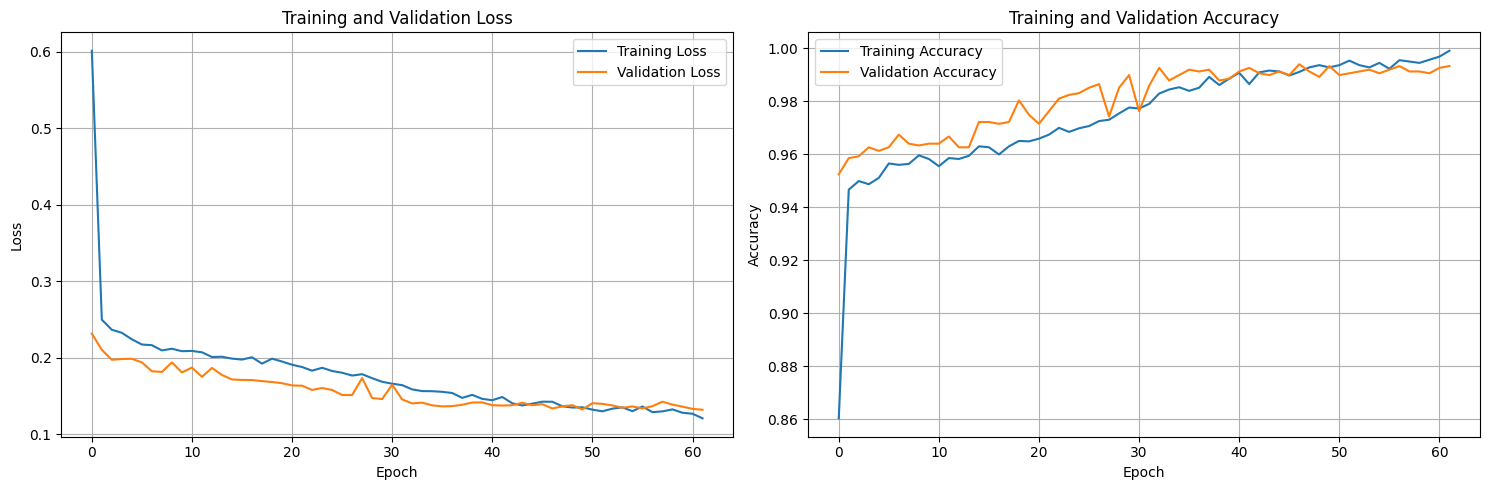

In [20]:
# 학습 곡선 시각화
train_loss = history['loss']
val_loss = history['val_loss']
train_accuracy = history['accuracy']
val_accuracy = history['val_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


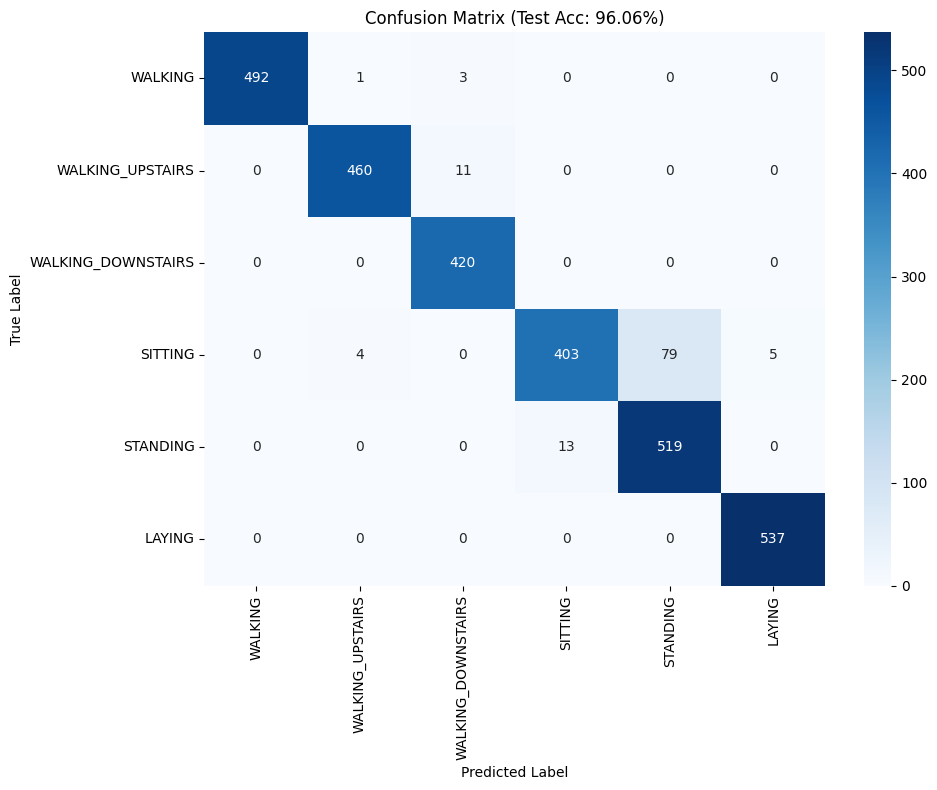

In [21]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.title(f'Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
